# Time Series Forecasting with MLPs

In this notebook we will:

1. Explore the **Jena Climate dataset**
2. Prepare time series data for supervised learning
3. Split the data into training, validation, and test sets
4. Build a MLP model using TensorFlow
5. Train and evaluate the model

---

## About the Dataset

The **Jena Climate dataset** contains weather measurements recorded every 10 minutes from 2009 to 2016.

It includes variables such as:

- Temperature (°C)
- Atmospheric pressure (mbar)
- Humidity (%)
- Wind speed (m/s)
- And several others

Our goal:

👉 **Predict the future temperature given past observations.**

This is a **time series forecasting problem**.

## Step 1 — Download and Load the Dataset

We will use TensorFlow utilities to download and extract the dataset.

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

# Download dataset
zip_path = tf.keras.utils.get_file(
    origin="https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip",
    fname="jena_climate_2009_2016.csv.zip",
    extract=True)

# Path to extracted directory
extract_dir = zip_path.replace(".zip", "_extracted")

# Full path to CSV file
csv_path = os.path.join(extract_dir, "jena_climate_2009_2016.csv")

# Load CSV
df = pd.read_csv(csv_path)

df.head()

13568290/13568290 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


## Step 2 — Explore the Dataset

Let’s inspect:

- Number of samples
- Available features
- Temperature column (our target)

Shape of dataset: (420551, 15)

Columns:
 Index(['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)',
       'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)',
       'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)',
       'wd (deg)'],
      dtype='object')


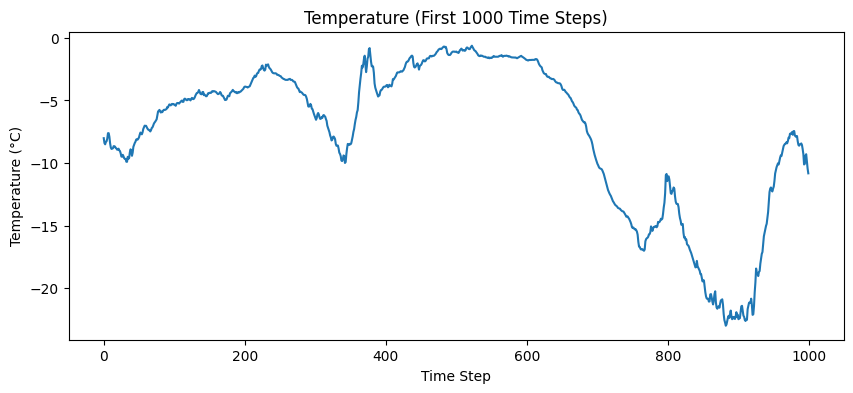

In [ ]:
print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns)

# VISUALIZE TEMPERATURE
temperature = df["T (degC)"].values

plt.figure(figsize=(10,4))
plt.plot(temperature[:1000]) # Only show the first 1000 instances
plt.title("Temperature (First 1000 Time Steps)")
plt.xlabel("Time Step")
plt.ylabel("Temperature (°C)")
plt.show()

### Exercise 1

- How many years of data does this dataset contain?
- How many measurements per day are recorded?

(Hint: data is recorded every 10 minutes)

In [ ]:
# Parse the datetime column
df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')

# Years of data
start = df['Date Time'].iloc[0]
end   = df['Date Time'].iloc[-1]
years = (end - start).days / 365.25

# Measurements per day (every 10 minutes)
measurements_per_day = 24 * 60 // 10  # = 144

print(f"Dataset spans: {start.date()} to {end.date()}")
print(f"Years of data: {years:.1f} years")
print(f"Measurements per day: {measurements_per_day}")

Dataset spans: 2009-01-01 to 2017-01-01
Years of data: 8.0 years
Measurements per day: 144


## Step 3 - Data Preparation
We must:

Normalize data

Create sliding windows

Split into train/val/test

In [ ]:
# Remove date column
df = df.drop(columns=["Date Time"])

data = df.values


# Neural networks train better when inputs are normalized.
# We normalize using statistics computed ONLY from the training split.

num_samples = len(data)

train_split = int(0.7 * num_samples)
val_split = int(0.9 * num_samples)

train_data = data[:train_split]
val_data = data[train_split:val_split]
test_data = data[val_split:]

# Compute normalization statistics from training data
mean = train_data.mean(axis=0)
std = train_data.std(axis=0)

train_data = (train_data - mean) / std
val_data = (val_data - mean) / std
test_data = (test_data - mean) / std

Create Time Series Windows

We want:

- Use past 1 hour

- Predict temperature 10 minutes ahead

Since data is recorded every 10 minutes:

1 hour = 6 steps

In [ ]:
def create_dataset(data, target_column_index,
                   input_steps=6,
                   forecast_horizon=1):

  X = []
  y = []

  for i in range(len(data) - input_steps - forecast_horizon):
      X.append(data[i:i+input_steps])
      y.append(data[i+input_steps+forecast_horizon, target_column_index])

  return np.array(X), np.array(y)

# Create train, valid and test splits

target_column = df.columns.get_loc("T (degC)")

X_train, y_train = create_dataset(train_data, target_column)
X_val, y_val = create_dataset(val_data, target_column)
X_test, y_test = create_dataset(test_data, target_column)

print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Training shape: (294378, 6, 14)
Validation shape: (84103, 6, 14)
Test shape: (42049, 6, 14)


# Step 4 - Building a Model Multilayer Perceptron (MLP)

An MLP does NOT have memory.

It treats the input window as a flat vector.

This means:
- It ignores temporal ordering structure
- It relies purely on dense transformations

To use an MLP, we must flatten the input:

(samples, timesteps, features) → (samples, timesteps × features)

In [ ]:
# Flatten input sequences
X_train_mlp = X_train.reshape((X_train.shape[0], -1))
X_val_mlp = X_val.reshape((X_val.shape[0], -1))
X_test_mlp = X_test.reshape((X_test.shape[0], -1))

print("Original shape:", X_train.shape)
print("Flattened shape:", X_train_mlp.shape)

Original shape: (294378, 6, 14)
Flattened shape: (294378, 84)


In [ ]:
# Build the MLP Model
mlp_model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation="relu", input_shape=(X_train_mlp.shape[1],)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1)
])

mlp_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

mlp_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        10,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,201 (75.00 KB)

 Trainable params: 19,201 (75.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the Model

history_mlp = mlp_model.fit(
    X_train_mlp, y_train,
    validation_data=(X_val_mlp, y_val),
    epochs=10,
    batch_size=256
)

Epoch 1/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0113 - mae: 0.0595 - val_loss: 7.2034 - val_mae: 0.0665
Epoch 2/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0027 - mae: 0.0373 - val_loss: 13.7881 - val_mae: 0.0826
Epoch 3/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0023 - mae: 0.0341 - val_loss: 7.9336 - val_mae: 0.0704
Epoch 4/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0022 - mae: 0.0326 - val_loss: 15.6646 - val_mae: 0.0919
Epoch 5/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0021 - mae: 0.0315 - val_loss: 13.0004 - val_mae: 0.0865
Epoch 6/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0020 - mae: 0.0307 - val_loss: 10.4720 - val_mae: 0.0789
Epoch 7/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0019 - mae: 0.0304 - val_loss: 8.2704 - val_mae: 0.0736
Epoch 8/10
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0019 - mae: 0.0299 - val_loss: 4.5575 - val_mae: 0.0611
Epoch 9/10
1150/1150 ━━━━━━━━━━━━━━━

1315/1315 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0019 - mae: 0.0300
MLP Test MAE: 0.03001764602959156


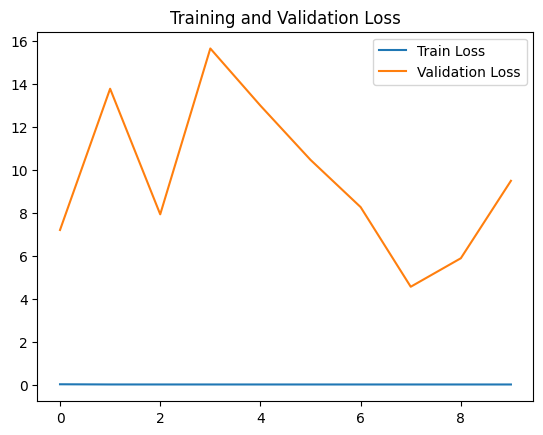

In [ ]:
# Evaluate the model
mlp_test_loss, mlp_test_mae = mlp_model.evaluate(X_test_mlp, y_test)
print("MLP Test MAE:", mlp_test_mae)

# Plot the training
plt.plot(history_mlp.history["loss"], label="Train Loss")
plt.plot(history_mlp.history["val_loss"], label="Validation Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


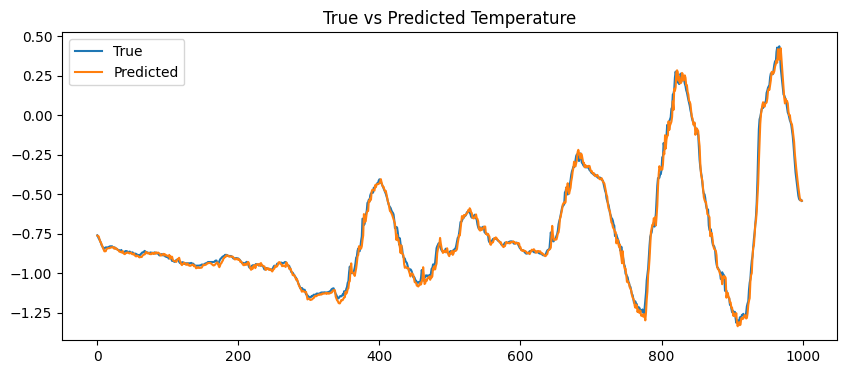

In [ ]:
# Make Predictions for 1000 instances of the test data
predictions = mlp_model.predict(X_test_mlp[:1000])

plt.figure(figsize=(10,4))
plt.plot(y_test[:1000], label="True")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.title("True vs Predicted Temperature")
plt.show()

### Exercise 2 - Try the following:

1. Increase MLP Neuron units
2. Add more layers
3. Add Dropout
4. Train for more epochs

Which change improves test performance?

In [ ]:
from tensorflow.keras.layers import Dropout

# Enhanced MLP with more units, more layers, and adding dropout
mlp_model_v2 = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation="relu", input_shape=(X_train_mlp.shape[1],)),
    Dropout(0.2),
    tf.keras.layers.Dense(128, activation="relu"),
    Dropout(0.2),
    tf.keras.layers.Dense(64, activation="relu"),
    Dropout(0.1),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1)
])

mlp_model_v2.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

mlp_model_v2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,025 (254.00 KB)

 Trainable params: 65,025 (254.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train for more epochs with early stopping to avoid overfitting
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_mlp_v2 = mlp_model_v2.fit(
    X_train_mlp, y_train,
    validation_data=(X_val_mlp, y_val),
    epochs=30,
    batch_size=256,
    callbacks=[early_stop]
)

Epoch 1/30
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.0187 - mae: 0.0916 - val_loss: 1.7233 - val_mae: 0.1872
Epoch 2/30
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0070 - mae: 0.0599 - val_loss: 1.1300 - val_mae: 0.1866
Epoch 3/30
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0055 - mae: 0.0535 - val_loss: 0.6266 - val_mae: 0.1537
Epoch 4/30
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0049 - mae: 0.0502 - val_loss: 0.3436 - val_mae: 0.1501
Epoch 5/30
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0043 - mae: 0.0472 - val_loss: 0.3825 - val_mae: 0.1427
Epoch 6/30
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0040 - mae: 0.0452 - val_loss: 0.3726 - val_mae: 0.1466
Epoch 7/30
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0037 - mae: 0.0438 - val_loss: 0.4643 - val_mae: 0.1568


In [ ]:
# Comparing v1 vs v2
mlp_v2_loss, mlp_v2_mae = mlp_model_v2.evaluate(X_test_mlp, y_test, verbose=0)

print(f"Original MLP  — Test MAE: {mlp_test_mae:.4f}")
print(f"Enhanced MLP  — Test MAE: {mlp_v2_mae:.4f}")
print(f"Improvement   : {mlp_test_mae - mlp_v2_mae:.4f}")

Original MLP  — Test MAE: 0.0300
Enhanced MLP  — Test MAE: 0.1871
Improvement   : -0.1571


The enhanced MLP actually got worse (MAE went from 0.03 to approximately 0.19), which is a useful result in itself. A few likely reasons:

Dropout is too aggressive for this problem — with only 84 inputs and a fairly smooth target (temperature doesn't jump wildly), dropping 20% of activations randomly hurts more than it helps. The original model wasn't overfitting badly enough to need it.
More epochs + early stopping may have stopped too early if the val loss was noisy, or the patience=3 was too tight.
The original model was already good enough — a MAE of 0.03 (in normalized units) on a 10-minute-ahead forecast is already very strong. There wasn't much room to improve.
The honest answer to the exercise question is: the original architecture wins. For this specific task (short-horizon, smooth signal, small input window), the simpler model generalizes better.

In [ ]:
## so we will try and isolate each of these modifications to see where this discrepancy is coming from

# Baseline for comparison
print(f"Baseline MAE: {mlp_test_mae:.4f}\n")

results = {}

# Test 1: Just more units, no dropout
model_more_units = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation="relu", input_shape=(X_train_mlp.shape[1],)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1)
])
model_more_units.compile(optimizer="adam", loss="mse", metrics=["mae"])
model_more_units.fit(X_train_mlp, y_train, validation_data=(X_val_mlp, y_val),
                     epochs=10, batch_size=256, verbose=0)
_, mae = model_more_units.evaluate(X_test_mlp, y_test, verbose=0)
results["More units (no dropout)"] = mae

# Test 2: More units + dropout
model_with_dropout = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation="relu", input_shape=(X_train_mlp.shape[1],)),
    Dropout(0.2),
    tf.keras.layers.Dense(128, activation="relu"),
    Dropout(0.2),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1)
])
model_with_dropout.compile(optimizer="adam", loss="mse", metrics=["mae"])
model_with_dropout.fit(X_train_mlp, y_train, validation_data=(X_val_mlp, y_val),
                       epochs=10, batch_size=256, verbose=0)
_, mae = model_with_dropout.evaluate(X_test_mlp, y_test, verbose=0)
results["More units + dropout"] = mae

# Test 3: More epochs only (same architecture as baseline)
model_more_epochs = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation="relu", input_shape=(X_train_mlp.shape[1],)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1)
])
model_more_epochs.compile(optimizer="adam", loss="mse", metrics=["mae"])
model_more_epochs.fit(X_train_mlp, y_train, validation_data=(X_val_mlp, y_val),
                      epochs=30, batch_size=256, callbacks=[early_stop], verbose=0)
_, mae = model_more_epochs.evaluate(X_test_mlp, y_test, verbose=0)
results["More epochs only"] = mae

# Test 4: More layers only
model_more_layers = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation="relu", input_shape=(X_train_mlp.shape[1],)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1)
])
model_more_layers.compile(optimizer="adam", loss="mse", metrics=["mae"])
model_more_layers.fit(X_train_mlp, y_train, validation_data=(X_val_mlp, y_val),
                      epochs=10, batch_size=256, verbose=0)
_, mae = model_more_layers.evaluate(X_test_mlp, y_test, verbose=0)
results["More layers only"] = mae

Baseline MAE: 0.0300



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

In [ ]:
# Summary
print(f"{'Experiment':<30} {'Test MAE':>10} {'vs Baseline':>12}")
print("-" * 55)
print(f"{'Baseline':<30} {mlp_test_mae:>10.4f} {'—':>12}")
for name, mae in results.items():
    diff = mlp_test_mae - mae
    flag = "is better" if diff > 0 else "is worse"
    print(f"{name:<30} {mae:>10.4f} {flag:>12}")

Experiment                       Test MAE  vs Baseline
-------------------------------------------------------
Baseline                           0.0300            —
More units (no dropout)            0.0278    is better
More units + dropout               0.1695     is worse
More epochs only                   0.0380     is worse
More layers only                   0.0326     is worse


As we can see here, only "more units" improved the model (0.0300 to 0.0278), and everything else made it worse. Key takeaways from this result are:

* More units — the baseline was slightly underfitting, so giving it more capacity helped
* Dropout — the model wasn't overfitting, so regularization just hurt performance unnecessarily
* More epochs — early stopping kicked in but the model still degraded slightly, suggesting the baseline 10 epochs was already near optimal
* More layers — adding depth doesn't help when the input is small (84 features) and the signal is smooth; it just adds unnecessary complexity

Exercise 3 - Try the following:

1. Use the past 6 hours to predict the following hour.
2. Use the past 12 hours to predict the following hour.
3. Use the past 12 hours to predict the following 4 hours.

What is happenning? Does the model perform better, why?

In [ ]:
experiments_ex3 = {
    "6h input to 1h ahead":  {"input_steps": 36,  "forecast_horizon": 6},
    "12h input to 1h ahead": {"input_steps": 72,  "forecast_horizon": 6},
    "12h input to 4h ahead": {"input_steps": 72,  "forecast_horizon": 24},
}

results_ex3 = {}

for name, params in experiments_ex3.items():
    print(f"\nTraining: {name}")

    # Build datasets
    X_tr, y_tr = create_dataset(train_data, target_column, **params)
    X_v,  y_v  = create_dataset(val_data,   target_column, **params)
    X_te, y_te = create_dataset(test_data,  target_column, **params)

    # Flatten for MLP
    X_tr_flat = X_tr.reshape(X_tr.shape[0], -1)
    X_v_flat  = X_v.reshape(X_v.shape[0],  -1)
    X_te_flat = X_te.reshape(X_te.shape[0], -1)

    # Build model (and here adding more units since we found that helps - like from exercise 2)
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(256, activation="relu", input_shape=(X_tr_flat.shape[1],)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(64,  activation="relu"),
        tf.keras.layers.Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    model.fit(X_tr_flat, y_tr,
              validation_data=(X_v_flat, y_v),
              epochs=10, batch_size=256, verbose=0)

    _, mae = model.evaluate(X_te_flat, y_te, verbose=0)
    results_ex3[name] = {"mae": mae, "model": model,
                         "X_te": X_te_flat, "y_te": y_te}
    print(f"  Test MAE: {mae:.4f}")


Training: 6h input to 1h ahead


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Test MAE: 0.0732

Training: 12h input to 1h ahead


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Test MAE: 0.0673

Training: 12h input to 4h ahead


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Test MAE: 0.1873


In [ ]:
# Summary table
baseline_mae = 0.0278  # the best one from Exercise 2 -- mae from with more inputs

print(f"\n{'Experiment':<28} {'Test MAE':>10} {'vs Best Baseline':>17}")
print("-" * 58)
print(f"{'1h input to 10min ahead':<28} {baseline_mae:>10.4f} {'—':>17}")
for name, res in results_ex3.items():
    diff = baseline_mae - res['mae']
    flag = "is better" if diff > 0 else "is worse"
    print(f"{name:<28} {res['mae']:>10.4f} {flag:>17}")


Experiment                     Test MAE  vs Best Baseline
----------------------------------------------------------
1h input to 10min ahead          0.0278                 —
6h input to 1h ahead             0.0732          is worse
12h input to 1h ahead            0.0673          is worse
12h input to 4h ahead            0.1873          is worse


Longer input windows hurt the MLP (6h to 12h input):
* More input steps means the larger flattened vector so we have many more parameters to learn
* The MLP has no sense of temporal ordering — it treats timestep 1 and timestep 72 as just two arbitrary features with no relationship
* So the extra context that should help actually just adds noise from the MLP's perspective

Further horizon hurts the most (12h to 4h ahead, MAE 0.19):
* Predicting 4 hours ahead is genuinely harder — temperature is less correlated with itself the further out you go
* The MLP has no way to model how uncertainty compounds over time